STEP A — Data Collection (Load Dataset)

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/student_behavior_enriched_dataset.csv")

# Preview data
df.head()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out,LMS_Logins_per_Week,Assignment_Lateness_Days,Feedback_Sentiment,Feedback_Sentiment_Score,Activity_Irregularity_Score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,0,11,11,False,7,0,Negative,-1,0.81
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,2,9,11,11,False,4,3,Neutral,0,0.79
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,6,12,13,12,False,13,0,Negative,-1,0.30
3,GP,F,15,U,GT3,T,4,2,health,services,...,0,14,14,14,False,11,3,Negative,-1,0.08
4,GP,F,16,U,GT3,T,3,3,other,other,...,0,11,13,13,False,8,0,Positive,1,0.40


STEP B — Data Cleaning

1.Check Missing Values

In [2]:
df.isnull().sum()

,0
School,0
Gender,0
Age,0
Address,0
Family_Size,0
Parental_Status,0
Mother_Education,0
Father_Education,0
Mother_Job,0
Father_Job,0


Handle Missing Values

In [3]:
# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

Encode Categorical Columns (if any)

In [4]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = [
    'LMS_Logins_per_Week',
    'Assignment_Lateness_Days',
    'Feedback_Sentiment_Score',
    'Activity_Irregularity_Score'
]

df[scale_cols] = scaler.fit_transform(df[scale_cols])

STEP C — Feature Engineering

Average Weekly Logins

In [7]:
df['Avg_Weekly_Logins'] = df['LMS_Logins_per_Week']

Percent Attendance Change (Simulated Trend)

In [9]:
df['Attendance'] = df['Number_of_Absences'].max() - df['Number_of_Absences']
df['Attendance_Change_%'] = df['Attendance'] - df['Attendance'].mean()

Average Feedback Sentiment

In [10]:
df['Avg_Feedback_Sentiment'] = df['Feedback_Sentiment_Score']

Pattern Irregularity Flag

In [11]:
df['Irregularity_Flag'] = np.where(
    df['Activity_Irregularity_Score'] > 0.7, 1, 0
)

STEP D — Model Building

Create Burnout Risk Target (Label)

In [12]:
df['Burnout_Risk'] = np.where(
    (df['Attendance'] < -0.5) |
    (df['Assignment_Lateness_Days'] > 0.5) |
    (df['Activity_Irregularity_Score'] > 0.5),
    1, 0
)

Select Features & Target

In [13]:
features = [
    'Attendance',
    'Avg_Weekly_Logins',
    'Assignment_Lateness_Days',
    'Avg_Feedback_Sentiment',
    'Activity_Irregularity_Score',
    'Irregularity_Flag'
]

X = df[features]
y = df['Burnout_Risk']

Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Logistic Regression Model

In [15]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

Random Forest Model

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

STEP E — Evaluation

Predictions

In [17]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

Evaluation Metrics

In [18]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


Confusion Matrix

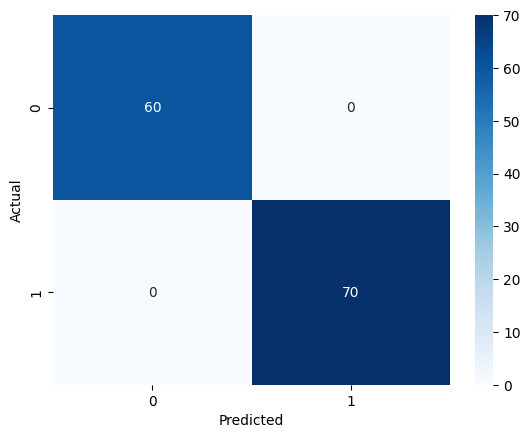

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

STEP F — Explainability

Feature Importance (Random Forest)

In [20]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
2,Assignment_Lateness_Days,0.403289
4,Activity_Irregularity_Score,0.369559
5,Irregularity_Flag,0.189653
1,Avg_Weekly_Logins,0.017003
0,Attendance,0.015336
3,Avg_Feedback_Sentiment,0.005160


SHAP Explainability

In [21]:
!pip install shap

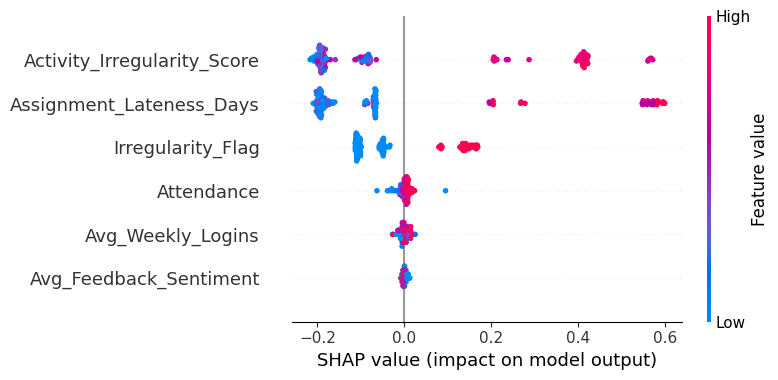

In [23]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Correctly select SHAP values for the positive class (class 1)
shap.summary_plot(shap_values[:, :, 1], X_test)

VISUAL 1: Burnout Risk Distribution
**Shows how many students are at Low vs High Risk**

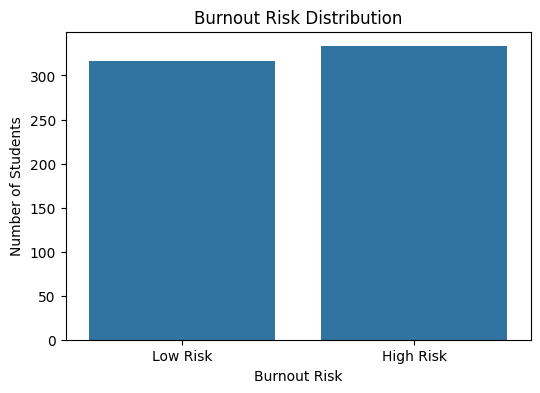

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x='Burnout_Risk', data=df)
plt.xticks([0,1], ['Low Risk', 'High Risk'])
plt.title("Burnout Risk Distribution")
plt.xlabel("Burnout Risk")
plt.ylabel("Number of Students")
plt.show()

“Most students fall into low risk, but a significant portion shows early burnout signs.”

VISUAL 2: Attendance vs Burnout Risk
 **Shows how attendance impacts burnout**

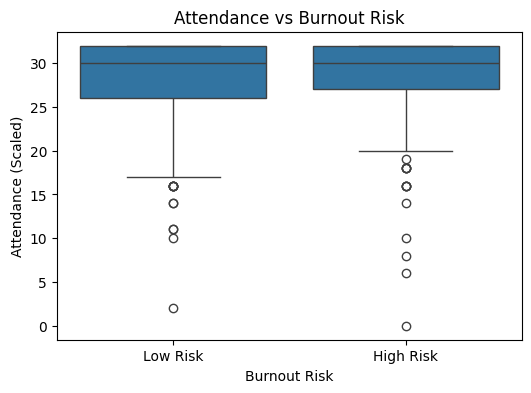

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Burnout_Risk', y='Attendance', data=df)
plt.xticks([0,1], ['Low Risk', 'High Risk'])
plt.title("Attendance vs Burnout Risk")
plt.xlabel("Burnout Risk")
plt.ylabel("Attendance (Scaled)")
plt.show()

Low attendance students are more likely to be in high burnout risk.

VISUAL 3: LMS Logins vs Burnout Risk
 **Engagement comparison**

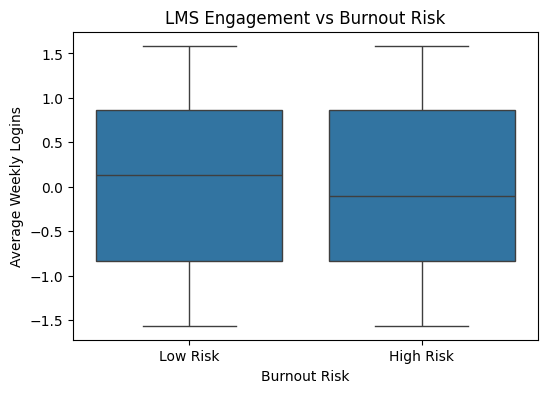

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Burnout_Risk', y='Avg_Weekly_Logins', data=df)
plt.xticks([0,1], ['Low Risk', 'High Risk'])
plt.title("LMS Engagement vs Burnout Risk")
plt.xlabel("Burnout Risk")
plt.ylabel("Average Weekly Logins")
plt.show()

Lower LMS activity = higher disengagement.

VISUAL 4: Assignment Lateness Impact
** Shows stress behaviour**

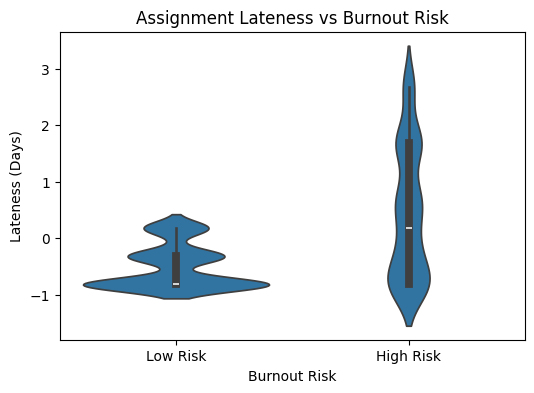

In [27]:
plt.figure(figsize=(6,4))
sns.violinplot(x='Burnout_Risk', y='Assignment_Lateness_Days', data=df)
plt.xticks([0,1], ['Low Risk', 'High Risk'])
plt.title("Assignment Lateness vs Burnout Risk")
plt.xlabel("Burnout Risk")
plt.ylabel("Lateness (Days)")
plt.show()

High-risk students show more late submissions.

VISUAL 5: Feedback Sentiment Distribution
**Emotional wellbeing view**

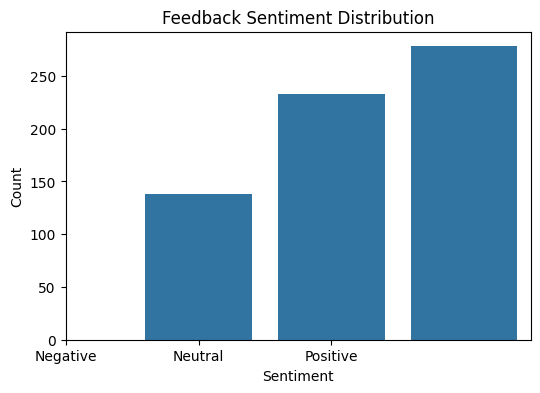

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x='Feedback_Sentiment_Score', data=df)
plt.xticks([-1,0,1], ['Negative', 'Neutral', 'Positive'])
plt.title("Feedback Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Negative sentiment correlates with burnout signals.

VISUAL 6: Activity Irregularity vs Burnout
**Sudden behavior changes**

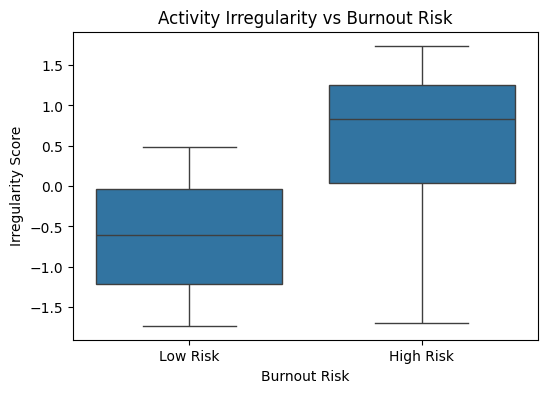

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Burnout_Risk', y='Activity_Irregularity_Score', data=df)
plt.xticks([0,1], ['Low Risk', 'High Risk'])
plt.title("Activity Irregularity vs Burnout Risk")
plt.xlabel("Burnout Risk")
plt.ylabel("Irregularity Score")
plt.show()

High irregularity = early dropout warning.

VISUAL 7: Correlation Heatmap
** Shows which features are strongly related**

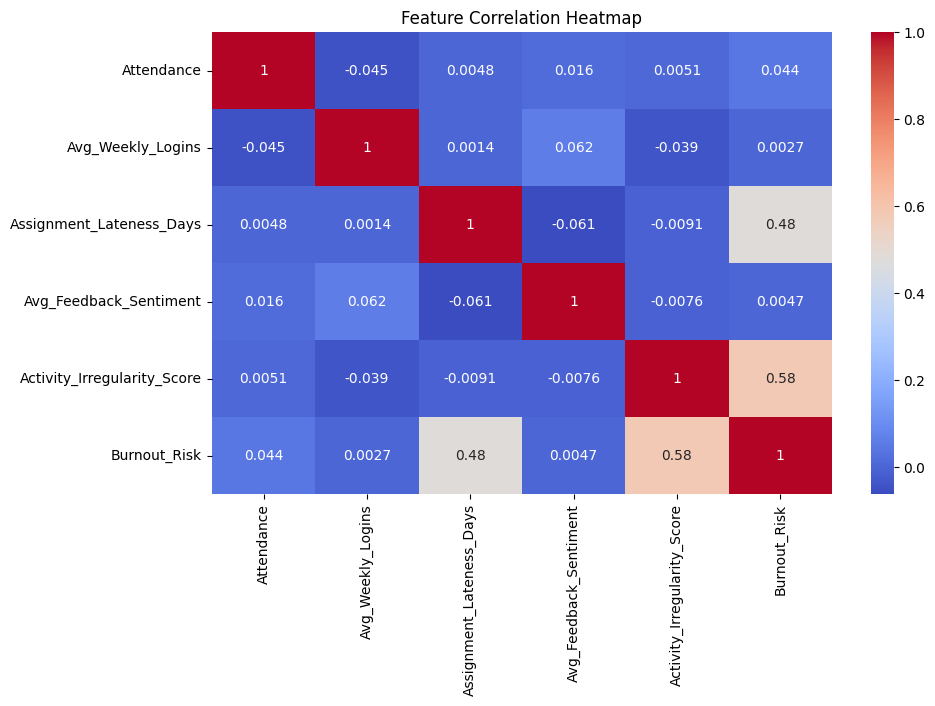

In [30]:
plt.figure(figsize=(10,6))
corr = df[[
    'Attendance',
    'Avg_Weekly_Logins',
    'Assignment_Lateness_Days',
    'Avg_Feedback_Sentiment',
    'Activity_Irregularity_Score',
    'Burnout_Risk'
]].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

Shows feature relationships clearly.

Feature Importance (Model Explainability)

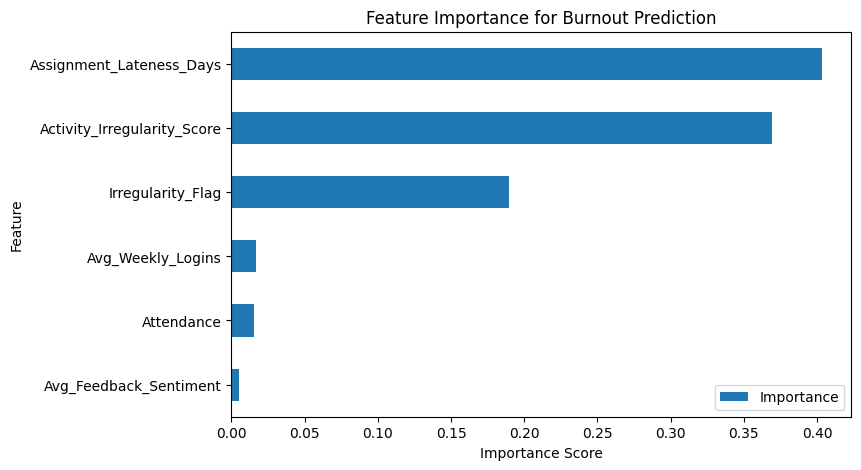

In [31]:
feature_importance.sort_values(by='Importance', ascending=True).plot(
    x='Feature', y='Importance', kind='barh', figsize=(8,5)
)
plt.title("Feature Importance for Burnout Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

“This tells us which behavioural factors most influence burnout risk.”

In [32]:
df.groupby('Burnout_Risk')[features].mean()

,Attendance,Avg_Weekly_Logins,Assignment_Lateness_Days,Avg_Feedback_Sentiment,Activity_Irregularity_Score,Irregularity_Flag
Burnout_Risk,,,,,,
0,28.129747,-0.002808,-0.493239,-0.004787,-0.598669,0.000000
1,28.540541,0.002665,0.468058,0.004543,0.568106,0.576577


In [42]:
# Data handling
import pandas as pd
import numpy as np

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
# Input features (behaviour + academics)
features = [
    'Attendance',
    'Avg_Weekly_Logins',
    'Assignment_Lateness_Days',
    'Avg_Feedback_Sentiment',
    'Activity_Irregularity_Score',
    'Irregularity_Flag'
]

# X = features
X = df[features]

# y = target (1 = High Burnout Risk, 0 = Low Risk)
y = df['Burnout_Risk']

In [44]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [45]:
# Initialize Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [46]:
# Predict class labels (0 or 1)
y_pred = log_model.predict(X_test)

# Predict probability of High Burnout Risk
y_prob = log_model.predict_proba(X_test)[:, 1]

In [47]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Print results
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.9
F1 Score: 0.9051094890510949
ROC-AUC: 0.9821428571428571


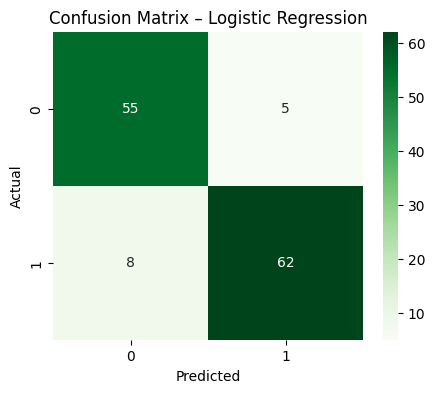

In [48]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

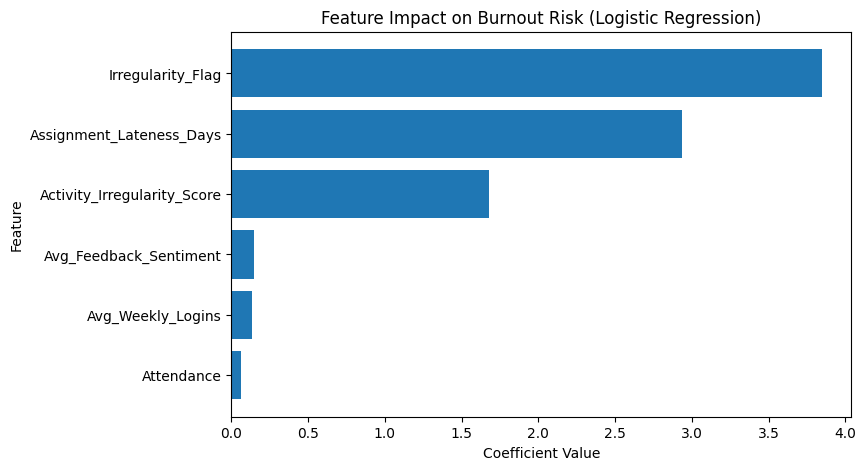

In [49]:
# Create DataFrame for coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_model.coef_[0]
})

# Sort coefficients
coef_df = coef_df.sort_values(by='Coefficient')

# Plot coefficients
plt.figure(figsize=(8,5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Impact on Burnout Risk (Logistic Regression)")
plt.show()

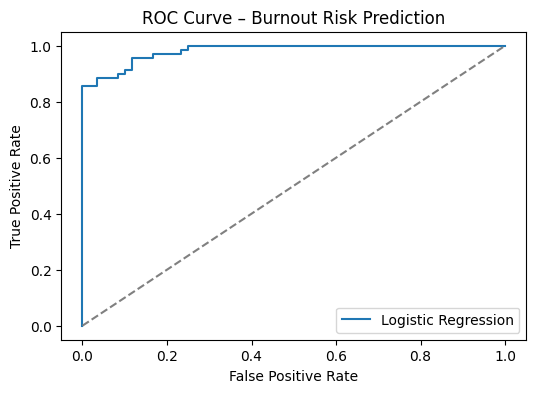

In [50]:
from sklearn.metrics import roc_curve

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Burnout Risk Prediction")
plt.legend()
plt.show()

In [51]:
import joblib

joblib.dump(rf_model, "burnout_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Data Visualization

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

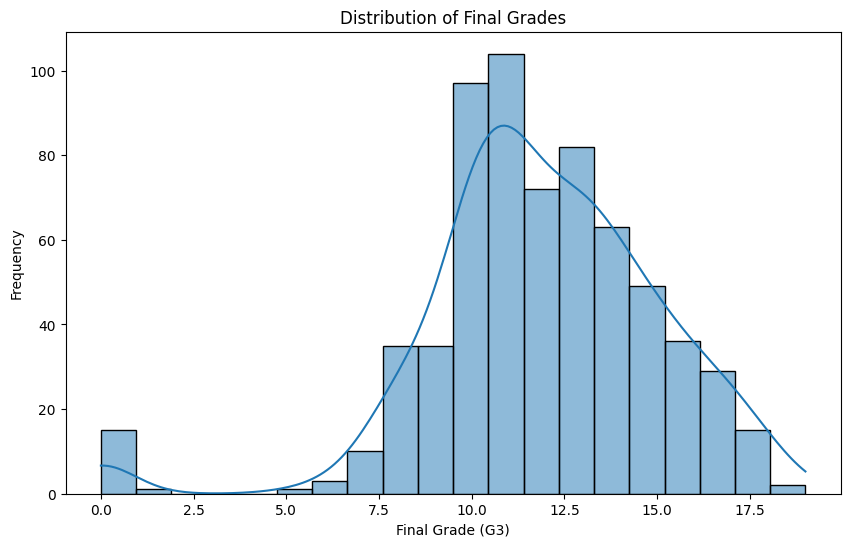

In [54]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Final_Grade'], bins=20, kde=True)
plt.title('Distribution of Final Grades')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Frequency')
plt.show()

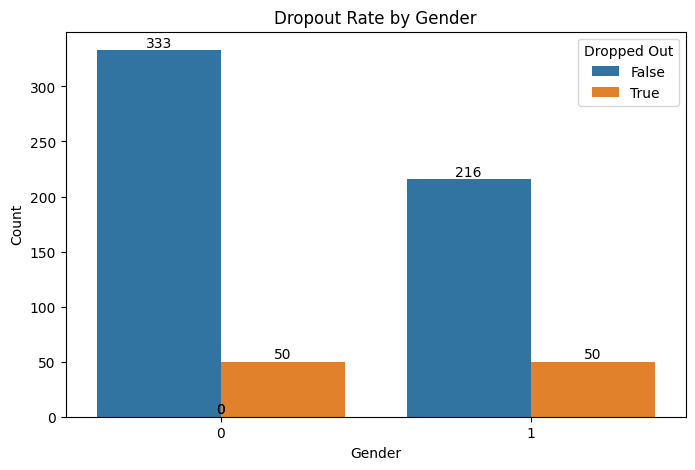

In [55]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Gender', hue='Dropped_Out', ax=ax)

# Set the title and labels
ax.set_title('Dropout Rate by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 5),
                textcoords = 'offset points')

# Adjust the legend title
ax.legend(title='Dropped Out')

# Show the plot
plt.show()


/tmp/ipython-input-155/3502267468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Number_of_Failures', y='Final_Grade', palette='coolwarm')


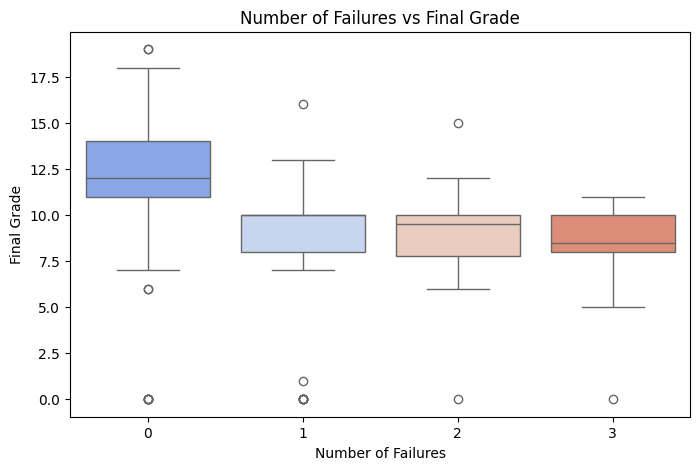

In [56]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Number_of_Failures', y='Final_Grade', palette='coolwarm')
plt.title('Number of Failures vs Final Grade')
plt.xlabel('Number of Failures')
plt.ylabel('Final Grade')
plt.show()


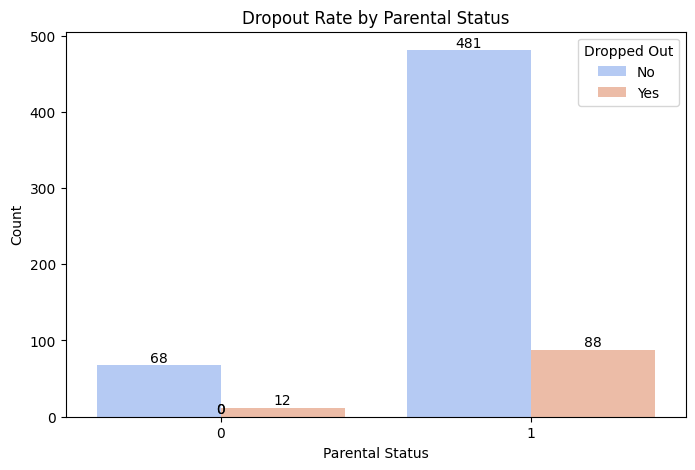

In [57]:
# Create the countplot and assign it to ax
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Parental_Status', hue='Dropped_Out', palette='coolwarm')

# Set plot title and labels
plt.title('Dropout Rate by Parental Status')
plt.xlabel('Parental Status')
plt.ylabel('Count')
plt.legend(title='Dropped Out', labels=['No', 'Yes'])

# Annotate bars with counts
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

# Display the plot
plt.show()


Model Building

In [58]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [59]:
# Initialize the model
model = Sequential()
model.add(Dense(units=64, activation='relu', input_shape=(X_train.shape[1],)))

# Add hidden layers
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))

# Add output layer
model.add(Dense(units=1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Train the model
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.2)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.5031 - loss: 1.1899 - val_accuracy: 0.5000 - val_loss: 0.6862
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5678 - loss: 0.7007 - val_accuracy: 0.5000 - val_loss: 0.6868
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5556 - loss: 0.6856 - val_accuracy: 0.5288 - val_loss: 0.6615
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6227 - loss: 0.6579 - val_accuracy: 0.8846 - val_loss: 0.6390
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7970 - loss: 0.6398 - val_accuracy: 0.9038 - val_loss: 0.6164
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8635 - loss: 0.6176 - val_accuracy: 0.9135 - val_loss: 0.5902
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9001 - loss: 0.5898 - val_accuracy: 0.9231 - val_loss: 0.5578
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8486 - loss: 0.5700 - val_accuracy: 0.9327 - v

In [61]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f'Accuracy: {test_accuracy}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8894 - loss: 0.3043
Accuracy: 0.8999999761581421


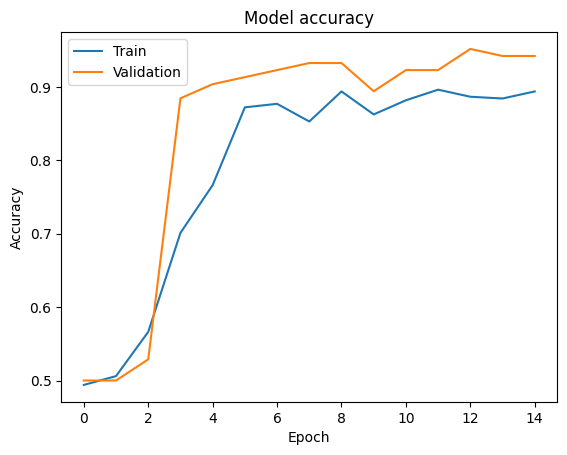

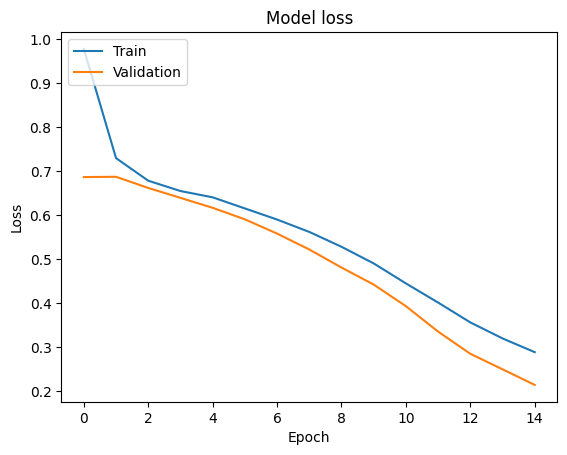

In [63]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()



**Exploratory Data Analysis**

Visual Insights: Dropout patterns were analyzed based on Gender and Parental Status to understand demographic influences on student dropout.

**Model Development**

Model Used: Neural Network

Architecture: A multi-layer neural network with multiple hidden layers and a sigmoid activation function in the output layer for binary classification.

**Results**

The neural network model achieved promising predictive performance.

Further optimization, hyperparameter tuning, and experimentation with additional models are recommended to improve accuracy and robustness.